In [1]:
import numpy as np

# these imports are shown explicitly in the notebook (so you don't have to import them here, 
#but they are listed here to specify all necessary imports for the notebook to run)

# import DataAnalysis.basic_functions as bf
# import DataAnalysis.basic_functions as bf

# Convert Processed Data From .json Files to Data to Analyze

## Read .json files and output as dictionary
- Using the scripts in DataProcessingGT, I output the data as .json files. The function get_energy_time_data in the basic_functions.py file opens the output .json files and returns the source energy data and time data as a dictionary object. 
- The data processing file puts the data in different subfolders in HistData folder depending on detector type, so you need to pass in the detector type (UDET or LDET) as a string. 
- My data processing script also outputs the energy and time data as, for example, "UDETenergy_data8622.json". So, you also need to pass in the run numbers associated with the files you want to analyze.

In [2]:
import DataAnalysis.basic_functions as bf

In [3]:
#example run numbers to test
run_numbers = [8622,8681]

In [4]:
#get the .json data for the specified run numbers and specified detector
UDETdata, UDETtime = bf.get_energy_time_data(run_numbers,'UDET')
LDETdata, LDETtime = bf.get_energy_time_data(run_numbers,'LDET')

In [5]:
#returns dictionary with data from each specified run number
UDETdata.keys()

dict_keys([8622, 8681])

In [6]:
#the data from each run number has the energy histogram values and the bin_edges
UDETdata[8622].keys()

dict_keys(['hist', 'bin_edges'])

In [7]:
#each entry to the histogram is broken up into subgroups (product of my data processing file)
UDETdata[8622]['hist'].keys()

dict_keys(['0', '1', '2'])

In [8]:
#each subgroup has the energy histogrma values for the pixels that were processed from my script
UDETdata[8622]['hist']['0'].keys()

dict_keys(['60', '76', '64', '67', '106', '110', '109'])

## Aggregate all the subgroups to a single run dictionary object
- Note, my script to process a run, splits the run into 15 sunrun groups to make the nabPy processing faster. The get_energy function in the basic_functions.py file sums up the 15 subrun subgroups from the data processing to a single energy dictionary for the full run. You need to pass in the dictionary obtained above and the run numbers

In [9]:
#convert the data the 15 subrun subgroups for the full run (note, this subgroup splitting is from my 
#script for data processing in DataProcessingGT/nabPyDataProcessing/get_pixels_hist_df.py)
UDETenergy = bf.get_energy(run_numbers,UDETdata)
LDETenergy = bf.get_energy(run_numbers,LDETdata)

## Specify energy histogram bin_edges
- Note, in my data processing script, everything has the same bin_edges, so I can use any entry to make the bin edges and use that for all my data.

In [10]:
#specify the bin_edges for the histograms
bin_edges = UDETdata[8622]['bin_edges']['0']['60']

# Fit Source Energy Histograms to Fit Functions and Output Result

## (1) Given just energy histogram values and bin edges
- This is a simple case to start to show you how the fitting code works (this is also incase you have your own data processing script and want to use my code to fit your data. I can get the energy histogram values from my processed data. The fit function expects a dictionary where the key is the pixel and the value is the energy histogram values. So to use my script, you will need to make a quick dictionary like that

In [11]:
#get energy histogram values from my data processing above
energy_hist_values = UDETenergy[8622]['60']

In [12]:
#create dictionary with the key as the pixel number and the values the list of energy histogram values
data = {}
data['60'] = energy_hist_values

- The 207Bi source fitting function is in the bi_fit_functions.py file. The function takes in the run number, the energy histogram values, the histogram bin edges, the pixel number, the fit region minimun, the fit region maximum, the number of peaks you are trying to fit in the region, the "peak_finder_props", the "initial_peak_sigmas", and a plot option. Note, if the plot option is False, the plot will be supressed.

- The "peak_finder_props" are properties for the scipy.signal library function find_peaks to try and initally find peaks in the spectrum. The "initial_peak_sigmas" are the inital guesses for the widths of the peaks you are trying to fit.

In [13]:
import DataAnalysis.bi_fit_functions as bi_fit

In [14]:
# specify inputs to the fit function
run_number = 8622
pixel = '60'
low_region = 1200
up_region = 1900
num_peaks = 3
peak_finder_props = (10,None,5,35,3,None,0.5,None)
initial_peak_sigmas = {'sig1':5,'sig2':6,'sig3':6}

/Users/arleeshelby/ManitobaWork_1374/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


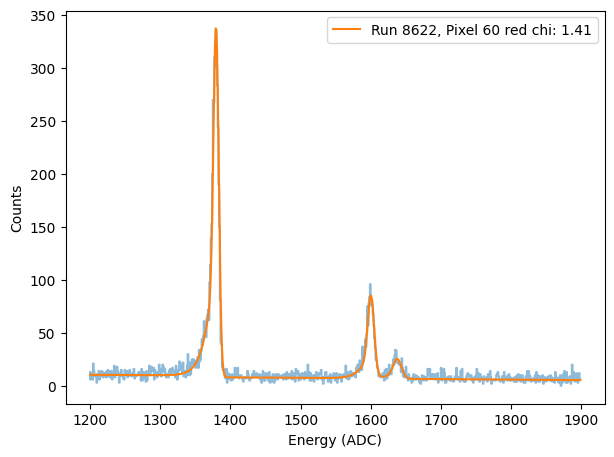

In [15]:
fit_results = bi_fit.get_UDETbi_fit_long(run_number,data,bin_edges,pixel,low_region,up_region,
                                         num_peaks,peak_finder_props,initial_peak_sigmas,plot=True)

- The fit function will output a dataframe with the fit result. It will output:
    - Fit $\chi^2$
    - Fit reducted $\chi^2$
    - Number of peaks used in the fit
    - Fit parameter value
    - Fit parameter uncertainty

In [95]:
fit_results

{'time': {},
 'chi2': 962.5079517570275,
 'red chi2': 1.4071753680658297,
 'num_peaks': {'value': 3, 'error': 0},
 'sig_ratio': {'value': 0.0960721556288151, 'error': 0.007194783914107449},
 'amp_ratio': {'value': 0.5997860628742395, 'error': 0.08614576572408053},
 'slope': {'value': -0.004856183484983405, 'error': 0.0022208982028141954},
 'intercept': {'value': 14.619400359366802, 'error': 3.9624364370444507},
 'amp1': {'value': 318.3850403941692, 'error': 9.192766667220702},
 'cen1': {'value': 1379.7006304185159, 'error': 0.14034930137407414},
 'sig1': {'value': 3.7572300276067923, 'error': 0.10133182789658625},
 'step1_ratio': {'value': 0.004559254091437412, 'error': 0.002031745051099142},
 'amp2': {'value': 75.15575528543715, 'error': 4.009233295554299},
 'cen2': {'value': 1600.6190724913822, 'error': 0.28151182454036067},
 'sig2': {'value': 4.595672006870966, 'error': 0.27558096981731767},
 'step2_ratio': {'value': -0.00304903733101268, 'error': 0.017245351884773448},
 'amp3': {'v

- You can change the inputs to the fit function to change the fit region
- This fit function is optimized for 207Bi
For example you can fit the Auger peak region by changing these parameters:

In [96]:
#specify new inputs to the fit function to fit a different region
low_region = 40
up_region = 400
num_peaks = 2
initial_peak_sigmas = {'sig1':5,'sig2':5}

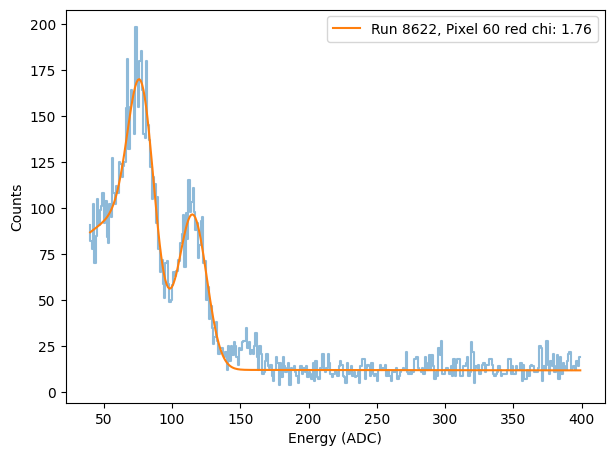

In [97]:
fit_results_auger = bi_fit.get_UDETbi_fit_long(run_number,data,bin_edges,pixel,low_region,up_region,
                                               num_peaks,peak_finder_props,initial_peak_sigmas,plot=True)

In [98]:
fit_results_auger

{'time': {},
 'chi2': 613.5037674832267,
 'red chi2': 1.7629418605839848,
 'num_peaks': {'value': 2, 'error': 0},
 'sig_ratio': {'value': 0.052817920914834504, 'error': 0.3024362873651524},
 'amp_ratio': {'value': 0.9999988325995772, 'error': 4.134015757232663},
 'slope': {'value': -0.0009287836607139184, 'error': 0.00408463489879822},
 'intercept': {'value': 12.242095657442508, 'error': 1.1467004586501042},
 'amp1': {'value': 127.67538159760204, 'error': 67.52152958268267},
 'cen1': {'value': 77.98450681894863, 'error': 5.307565448617129},
 'sig1': {'value': 9.666545090415447, 'error': 2.682268006122991},
 'step1_ratio': {'value': 0.5313105231206623, 'error': 0.8866706475459649},
 'amp2': {'value': 81.03884119741863, 'error': 44.54349695969275},
 'cen2': {'value': 115.60627382414327, 'error': 5.012948595396498},
 'sig2': {'value': 9.99085634970611, 'error': 1.7942006674674296},
 'step2_ratio': {'value': -0.09999999016036162, 'error': 1.1961093217059988}}

## (2) Given data for multiple runs and a single pixel
- Following my data processing set up, I have a fit function that made to loop through dictionaries of energy histogram value data for many runs that have many pixels. 
- My code is also optimized to fit 207Bi source data
    - There are 3 fit regions for the 207Bi source data
    - This fit function will fit all three regions and return the results for each region
- The data you pass in is expected to be a nested dictionary where the first key is the run number, the second key is the pixel number, and the values are the energy histogram values
- Note, the default detector is UDET and the default low fit region for the Auger line is 40

In [99]:
UDETenergy.keys()

dict_keys([8622, 8681])

In [100]:
UDETenergy[8622].keys()

dict_keys(['60', '76', '64', '67', '106', '110', '109'])

- As an example, I will do all runs, but only try to fit pixel 60 in each run

In [102]:
test_pixel = '60'

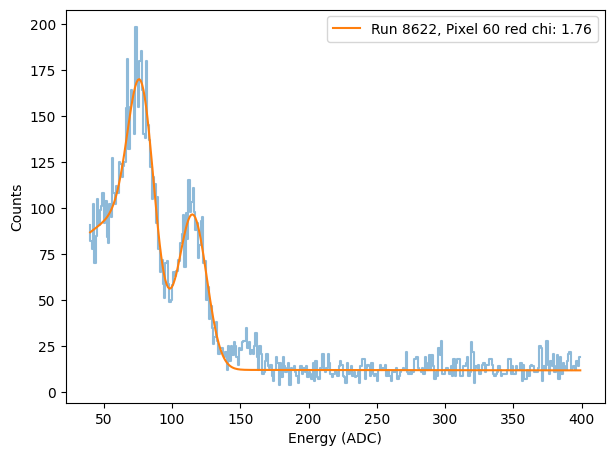

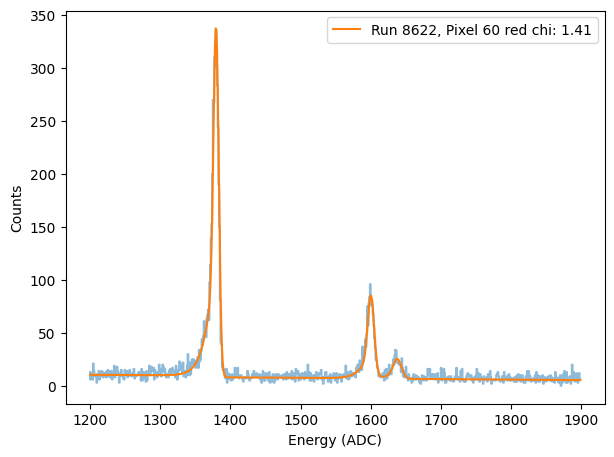

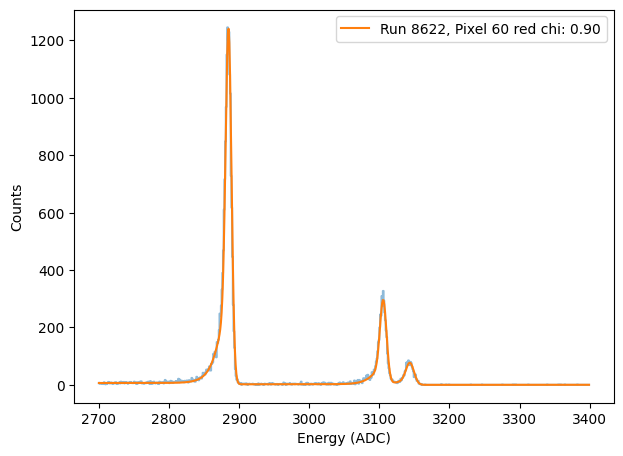

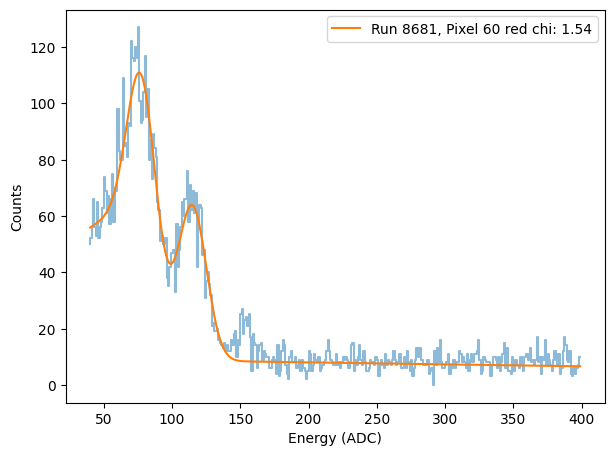

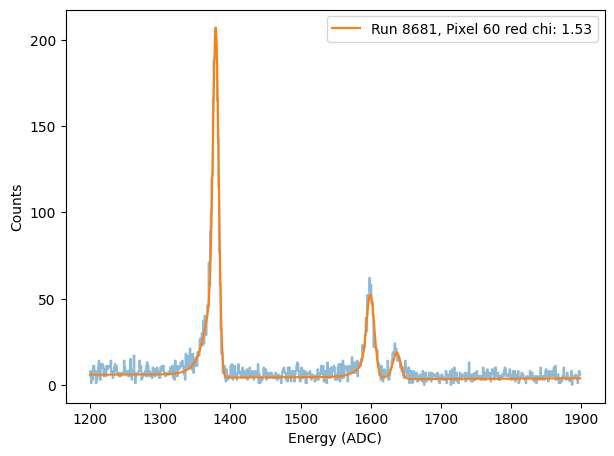

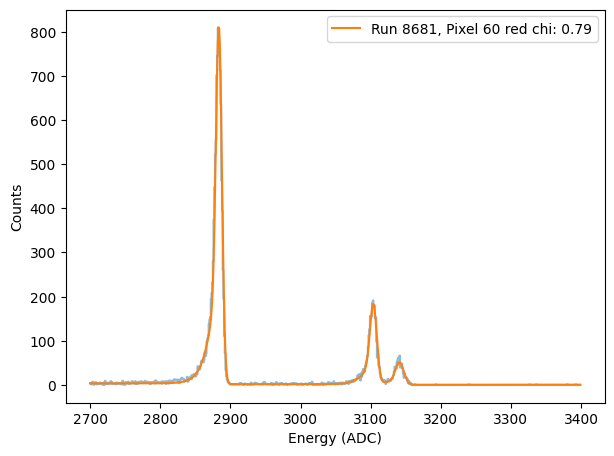

In [103]:
fit_results_60 = bi_fit.get_UDETbi_fit_results(UDETenergy, bin_edges, test_pixel, run_numbers, plot=True)

- The output now is a nested dictionary where the first key is the run number, which holds the fit results from all three fit regions
     - 0: Auger fit region
     - 1: intermediate conversion electron region
     - 2: higher-lying conversion electron region

In [104]:
fit_results_60

{8622: {0: {'time': {},
   'chi2': 613.5037674832267,
   'red chi2': 1.7629418605839848,
   'num_peaks': {'value': 2, 'error': 0},
   'sig_ratio': {'value': 0.052817920914834504, 'error': 0.3024362873651524},
   'amp_ratio': {'value': 0.9999988325995772, 'error': 4.134015757232663},
   'slope': {'value': -0.0009287836607139184, 'error': 0.00408463489879822},
   'intercept': {'value': 12.242095657442508, 'error': 1.1467004586501042},
   'amp1': {'value': 127.67538159760204, 'error': 67.52152958268267},
   'cen1': {'value': 77.98450681894863, 'error': 5.307565448617129},
   'sig1': {'value': 9.666545090415447, 'error': 2.682268006122991},
   'step1_ratio': {'value': 0.5313105231206623, 'error': 0.8866706475459649},
   'amp2': {'value': 81.03884119741863, 'error': 44.54349695969275},
   'cen2': {'value': 115.60627382414327, 'error': 5.012948595396498},
   'sig2': {'value': 9.99085634970611, 'error': 1.7942006674674296},
   'step2_ratio': {'value': -0.09999999016036162,
    'error': 1.1961

## (3) Given data for numtiple runs and multiple pixels
- Following the previous section, I also have a function that will successivly fit data, with the same structure as shown a previous section, for multiple runs and multiple pixels
- This function is the the basic_functions.py file
- Note, for this function you must specify the detector type or it won't work

In [140]:
test_pixels = ['60','76']

In [141]:
UDET_test_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, 
                                 test_pixels, run_numbers, plot=False,detector_type='UDET')

- The output will be a nested dictionary of the fit results

In [142]:
UDET_test_df.keys()

dict_keys(['60', '76'])

In [143]:
UDET_test_df['60'].keys()

dict_keys([8622, 8681])

In [144]:
UDET_test_df['60'][8622]

{0: {'time': {},
  'chi2': 613.5037674832267,
  'red chi2': 1.7629418605839848,
  'num_peaks': {'value': 2, 'error': 0},
  'sig_ratio': {'value': 0.052817920914834504, 'error': 0.3024362873651524},
  'amp_ratio': {'value': 0.9999988325995772, 'error': 4.134015757232663},
  'slope': {'value': -0.0009287836607139184, 'error': 0.00408463489879822},
  'intercept': {'value': 12.242095657442508, 'error': 1.1467004586501042},
  'amp1': {'value': 127.67538159760204, 'error': 67.52152958268267},
  'cen1': {'value': 77.98450681894863, 'error': 5.307565448617129},
  'sig1': {'value': 9.666545090415447, 'error': 2.682268006122991},
  'step1_ratio': {'value': 0.5313105231206623, 'error': 0.8866706475459649},
  'amp2': {'value': 81.03884119741863, 'error': 44.54349695969275},
  'cen2': {'value': 115.60627382414327, 'error': 5.012948595396498},
  'sig2': {'value': 9.99085634970611, 'error': 1.7942006674674296},
  'step2_ratio': {'value': -0.09999999016036162, 'error': 1.1961093217059988}},
 1: {'time

# Calibrate Data From Fit Results
- To calibrate the data, we need the centroids and their uncertainties
- We need to then extract the peak centers and uncertainties from the nested fit result dictionary 

## Get peak values from fit result output (for multiple runs and multiple pixels)
- I use a function in the basic_functions.py file that extracts the centroids of all fit that were stored in the result dictionary
- This function looks through all fit regions for each pixel and run
- The function defines up to 8 207Bi peaks that can be used in the calibration
    - Peak 1 and 2 (Auger peaks)
    - Peaks 3, 4, and 5 (intermediate conversion electron peaks)
    - Peaks 6, 7, and 8 (higher-lying conversion electron peaks)
- You also need to pass in the expected keV values and errors for those peaks
    - Note, I am currently using Jin's simulated results for 207Bi (could also use nndc values and error for example)

In [146]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [151]:
test_calibration_values = bf.get_cal_peaks_df(UDET_test_df,simulated_keV_values,simulated_keV_errors)

In [154]:
#example output for pixel 60, run 8622
test_calibration_values['60'][8622]

{'peak1': {'value': 77.98450681894863,
  'error': 5.307565448617129,
  'keV value': 25.269661,
  'keV error': 0.005846},
 'peak2': {'value': 115.60627382414327,
  'error': 5.012948595396498,
  'keV value': 38.276915,
  'keV error': 0.0028},
 'peak3': {'value': 1379.7006304185159,
  'error': 0.14034930137407414,
  'keV value': 453.020179,
  'keV error': 0.003731},
 'peak4': {'value': 1600.6190724913822,
  'error': 0.28151182454036067,
  'keV value': 525.714534,
  'keV error': 0.005186},
 'peak5': {'value': 1638.2372800818252,
  'error': 0.7924236383631026,
  'keV value': 538.039,
  'keV error': 0.013013},
 'peak6': {'value': 2884.9668982064886,
  'error': 0.0539710850078287,
  'keV value': 947.193705,
  'keV error': 0.002459},
 'peak7': {'value': 3105.609982934326,
  'error': 0.1037728712243313,
  'keV value': 1019.613371,
  'keV error': 0.004933},
 'peak8': {'value': 3143.6829667543166,
  'error': 0.22666956706312294,
  'keV value': 1032.008589,
  'keV error': 0.012757}}

- To calibrate the data, I have a function in basic_functions.py that takes in the calibration peak values and the type of calibration you want to do 
- Right now, you can choose between a linear and quadratic calibration
- The output will be a nested dictionary of lmfit result objects (an example of the lmfit result object is shown below)

In [162]:
calibration_results = bf.calibrate_data(test_calibration_values,calibration_order='linear')

In [163]:
calibration_results

{'60': {8622: <lmfit.minimizer.MinimizerResult at 0x1546026d0>,
  8681: <lmfit.minimizer.MinimizerResult at 0x1545f61d0>},
 '76': {8622: <lmfit.minimizer.MinimizerResult at 0x1545f7250>,
  8681: <lmfit.minimizer.MinimizerResult at 0x1545a5950>}}

In [164]:
# example lmfit result object
calibration_results['60'][8622]